In [1]:
# ============================================
# CELL 1: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [2]:
# ============================================
# CELL 2: Load Dataset dari URL (Langsung download)
# ============================================
# URL dataset German Credit dari GitHub
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv"

# Nama kolom berdasarkan dokumentasi dataset
column_names = [
    'status_checking_account', 'duration_month', 'credit_history', 'purpose',
    'credit_amount', 'savings_account_bond', 'present_employment_since',
    'installment_rate', 'personal_status_sex', 'other_debtors',
    'present_residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'number_existing_credits', 'job', 'num_people_liable',
    'telephone', 'foreign_worker', 'risk'
]

# Load dataset
df = pd.read_csv(url, header=None, names=column_names)

print(f"✅ Dataset berhasil di-load!")
print(f"📊 Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\n📋 5 baris pertama:")
print(df.head())

✅ Dataset berhasil di-load!
📊 Ukuran dataset: 1000 baris, 21 kolom

📋 5 baris pertama:
  status_checking_account  duration_month credit_history purpose  \
0                     A11               6            A34     A43   
1                     A12              48            A32     A43   
2                     A14              12            A34     A46   
3                     A11              42            A32     A42   
4                     A11              24            A33     A40   

   credit_amount savings_account_bond present_employment_since  \
0           1169                  A65                      A75   
1           5951                  A61                      A73   
2           2096                  A61                      A74   
3           7882                  A61                      A74   
4           4870                  A61                      A73   

   installment_rate personal_status_sex other_debtors  ...  property age  \
0                 4            

In [3]:
# ============================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================
print("\n" + "="*50)
print("INFORMASI DATASET")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("CEK MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("DISTRIBUSI TARGET (Risk)")
print("="*50)
# Ubah target: 1=Good (Kredit Bagus), 0=Bad (Kredit Buruk)
df['risk'] = df['risk'].map({1: 1, 2: 0})
print(df['risk'].value_counts())
print(f"Persentase Good: {df['risk'].value_counts(normalize=True)[1]*100:.2f}%")
print(f"Persentase Bad: {df['risk'].value_counts(normalize=True)[0]*100:.2f}%")


INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   status_checking_account   1000 non-null   object
 1   duration_month            1000 non-null   int64 
 2   credit_history            1000 non-null   object
 3   purpose                   1000 non-null   object
 4   credit_amount             1000 non-null   int64 
 5   savings_account_bond      1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate          1000 non-null   int64 
 8   personal_status_sex       1000 non-null   object
 9   other_debtors             1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age                       1000 non-null   int64 
 13  other_installment_plans   1000 non-null   object
 14  housin

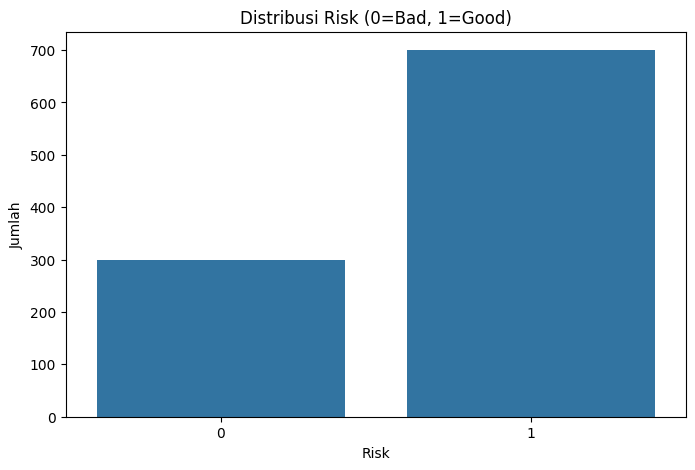

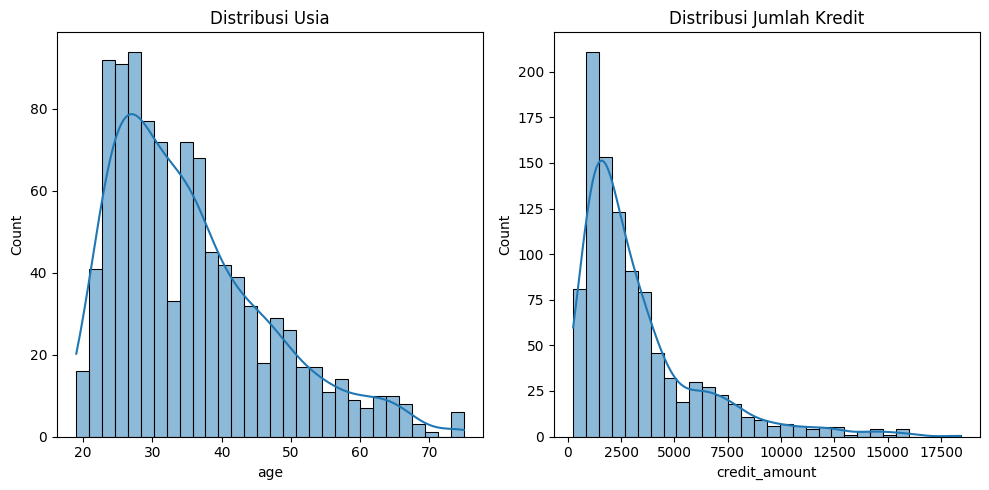

In [4]:
# ============================================
# CELL 4: Visualisasi Data
# ============================================
# Plot distribusi target
plt.figure(figsize=(8, 5))
sns.countplot(x='risk', data=df)
plt.title('Distribusi Risk (0=Bad, 1=Good)')
plt.xlabel('Risk')
plt.ylabel('Jumlah')
plt.show()

# Plot age distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribusi Usia')

# Plot credit amount distribution
plt.subplot(1, 2, 2)
sns.histplot(df['credit_amount'], bins=30, kde=True)
plt.title('Distribusi Jumlah Kredit')
plt.tight_layout()
plt.show()

In [5]:
# ============================================
# CELL 5: Preprocessing - Handle Missing Values
# ============================================
# Cek missing values
print("Missing values sebelum preprocessing:")
print(df.isnull().sum())

# Dataset ini tidak memiliki missing values, tapi kita tetap proses
# Jika ada missing values, kita isi dengan modus (untuk kategorikal) atau median (untuk numerik)
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("\n✅ Missing values telah di-handle")

Missing values sebelum preprocessing:
status_checking_account     0
duration_month              0
credit_history              0
purpose                     0
credit_amount               0
savings_account_bond        0
present_employment_since    0
installment_rate            0
personal_status_sex         0
other_debtors               0
present_residence_since     0
property                    0
age                         0
other_installment_plans     0
housing                     0
number_existing_credits     0
job                         0
num_people_liable           0
telephone                   0
foreign_worker              0
risk                        0
dtype: int64

✅ Missing values telah di-handle


/tmp/ipykernel_557/3563615597.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
/tmp/ipykernel_557/3563615597.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [6]:
# ============================================
# CELL 6: Preprocessing - Encoding Categorical Variables
# ============================================
# Pisahkan fitur dan target
X = df_clean.drop('risk', axis=1)
y = df_clean['risk']

# Identifikasi kolom kategorikal
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Kolom kategorikal: {list(categorical_cols)}")

# Encoding menggunakan LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    print(f"✅ {col} telah di-encode")

print("\n✅ Encoding selesai!")

Kolom kategorikal: ['status_checking_account', 'credit_history', 'purpose', 'savings_account_bond', 'present_employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
✅ status_checking_account telah di-encode
✅ credit_history telah di-encode
✅ purpose telah di-encode
✅ savings_account_bond telah di-encode
✅ present_employment_since telah di-encode
✅ personal_status_sex telah di-encode
✅ other_debtors telah di-encode
✅ property telah di-encode
✅ other_installment_plans telah di-encode
✅ housing telah di-encode
✅ job telah di-encode
✅ telephone telah di-encode
✅ foreign_worker telah di-encode

✅ Encoding selesai!


In [7]:
# ============================================
# CELL 7: Preprocessing - Feature Scaling
# ============================================
# Standardisasi fitur numerik
numerical_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"✅ Scaling selesai! {len(numerical_cols)} kolom telah di-standardisasi")

✅ Scaling selesai! 20 kolom telah di-standardisasi


In [9]:
import os

# ============================================
# CELL 8: Simpan Data yang Sudah Diproses
# ============================================
# Gabungkan X dan y
df_final = X_scaled.copy()
df_final['risk'] = y.values

# Buat folder preprocessing jika belum ada
output_dir = 'preprocessing'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Simpan ke folder preprocessing
df_final.to_csv(os.path.join(output_dir, 'german_processed.csv'), index=False)
print(f"✅ Data processed disimpan di '{os.path.join(output_dir, 'german_processed.csv')}'")
print(f"📊 Shape akhir: {df_final.shape}")

# Tampilkan 5 baris pertama data yang sudah diproses
print("\n📋 5 baris pertama data yang sudah diproses:")
print(df_final.head())

✅ Data processed disimpan di 'preprocessing/german_processed.csv'
📊 Shape akhir: (1000, 21)

📋 5 baris pertama data yang sudah diproses:
   status_checking_account  duration_month  credit_history   purpose  \
0                -1.254566       -1.236478        1.344014  0.264068   
1                -0.459026        2.248194       -0.503428  0.264068   
2                 1.132053       -0.738668        1.344014  1.359785   
3                -1.254566        1.750384       -0.503428 -0.101171   
4                -1.254566        0.256953        0.420293 -1.196889   

   credit_amount  savings_account_bond  present_employment_since  \
0      -0.745131              1.833169                  1.338078   
1       0.949817             -0.699707                 -0.317959   
2      -0.416562             -0.699707                  0.510060   
3       1.634247             -0.699707                  0.510060   
4       0.566664             -0.699707                 -0.317959   

   installment_rate  

In [10]:
# ============================================
# CELL 9: Split Data untuk Training
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Testing set: {X_test.shape[0]} samples")

📊 Training set: 800 samples
📊 Testing set: 200 samples


In [11]:
# ============================================
# CELL 10: Training Model Sederhana (Verifikasi)
# ============================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Akurasi model: {accuracy:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

print("\n✅ EKSPERIMEN SELESAI! Data siap untuk dilanjutkan ke Kriteria 2.")

🎯 Akurasi model: 0.7850

📋 Classification Report:
              precision    recall  f1-score   support

     Bad (0)       0.70      0.50      0.58        60
    Good (1)       0.81      0.91      0.86       140

    accuracy                           0.79       200
   macro avg       0.75      0.70      0.72       200
weighted avg       0.78      0.79      0.77       200


✅ EKSPERIMEN SELESAI! Data siap untuk dilanjutkan ke Kriteria 2.
